In [20]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import layers,models
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
import os
from google.colab import drive
drive.mount('/content/drive/')
data_dir="/content/drive/MyDrive/animal_data"

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [22]:
img_size=(128,128)
batch_size=32

training_data=tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 2327 files belonging to 5 classes.
Using 1862 files for training.


In [23]:
validation_data=tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 2327 files belonging to 5 classes.
Using 465 files for validation.


In [24]:
class_names=training_data.class_names
num_class_names=len(class_names)
num_class_names

5

In [25]:
augment=tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1)
])

In [26]:
AUTOTUNE=tf.data.AUTOTUNE

training_data=training_data.map(lambda x,y:(augment(x,training=True)/255.0,y)).prefetch(AUTOTUNE)
validation_data=validation_data.map(lambda x,y:(x/255.0,y)).prefetch(AUTOTUNE)


In [49]:
# Build the Full Custom ResNet

def build_model(num_classes,input_shape=(128,128,3)):

  base_model=tf.keras.applications.MobileNetV2(
      input_shape=(128,128,3),
      include_top=False,
      weights='imagenet'
  )

  base_model.trainable=False

  inputs=layers.Input(shape=input_shape)

  x=base_model(inputs,training=False)

  x=layers.GlobalAveragePooling2D()(x)
  x=layers.Dense(256,activation='relu')(x)
  x=layers.Dropout(0.4)(x)
  outputs=layers.Dense(num_classes,activation="softmax")(x)

  model=tf.keras.Model(inputs,outputs)
  return model


model=build_model(num_class_names)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [50]:
callbacks=[
    tf.keras.callbacks.EarlyStopping(patience=5,restore_best_weights=True,monitor="val_accuracy"),
    tf.keras.callbacks.ModelCheckpoint("best_wildlife_model.keras",save_best_only=True,monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=3,verbose=1)
]

In [51]:
from flax.nnx import optimizer
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [52]:
history=model.fit(
    training_data,
    validation_data=validation_data,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.8217 - loss: 0.5342 - val_accuracy: 0.9677 - val_loss: 0.0908 - learning_rate: 0.0010
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 236ms/step - accuracy: 0.9162 - loss: 0.2454 - val_accuracy: 0.9828 - val_loss: 0.0484 - learning_rate: 0.0010
Epoch 3/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 238ms/step - accuracy: 0.9307 - loss: 0.1862 - val_accuracy: 0.9849 - val_loss: 0.0548 - learning_rate: 0.0010
Epoch 4/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - accuracy: 0.9307 - loss: 0.2023 - val_accuracy: 0.9828 - val_loss: 0.0527 - learning_rate: 0.0010
Epoch 5/15
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9399 - loss: 0.1655
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - accuracy: 0.9398 - loss: 0.1574 - val_accuracy: 0.9763 - val_loss: 0.0703 - learning_rate: 0.0010
Epoch 6/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 224ms/step - accuracy: 0.9538 - loss: 0.1270

In [54]:
model.layers[1].trainable=True
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [55]:
callbacks2=[
    tf.keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True,monitor="val_accuracy"),
    tf.keras.callbacks.ModelCheckpoint("best_wildlife_model.keras",save_best_only=True,monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=0.3,patience=4,verbose=1)
]

In [56]:
history1=model.fit(
    training_data,
    validation_data=validation_data,
    epochs=10,
    callbacks=callbacks2
)

Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 105s 856ms/step - accuracy: 0.8813 - loss: 0.3401 - val_accuracy: 0.9871 - val_loss: 0.0464 - learning_rate: 1.0000e-05
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 233ms/step - accuracy: 0.9253 - loss: 0.2234 - val_accuracy: 0.9849 - val_loss: 0.0439 - learning_rate: 1.0000e-05
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 233ms/step - accuracy: 0.9307 - loss: 0.1904 - val_accuracy: 0.9871 - val_loss: 0.0447 - learning_rate: 1.0000e-05
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 234ms/step - accuracy: 0.9398 - loss: 0.1588 - val_accuracy: 0.9806 - val_loss: 0.0459 - learning_rate: 1.0000e-05
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 21s 239ms/step - accuracy: 0.9484 - loss: 0.1528 - val_accuracy: 0.9849 - val_loss: 0.0393 - learning_rate: 1.0000e-05
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 240ms/step - accuracy: 0.9560 - loss: 0.1243 - val_accuracy: 0.9871 - val_loss: 0.0367 - learning_rate: 1.0000e-05
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 252ms/step - ac

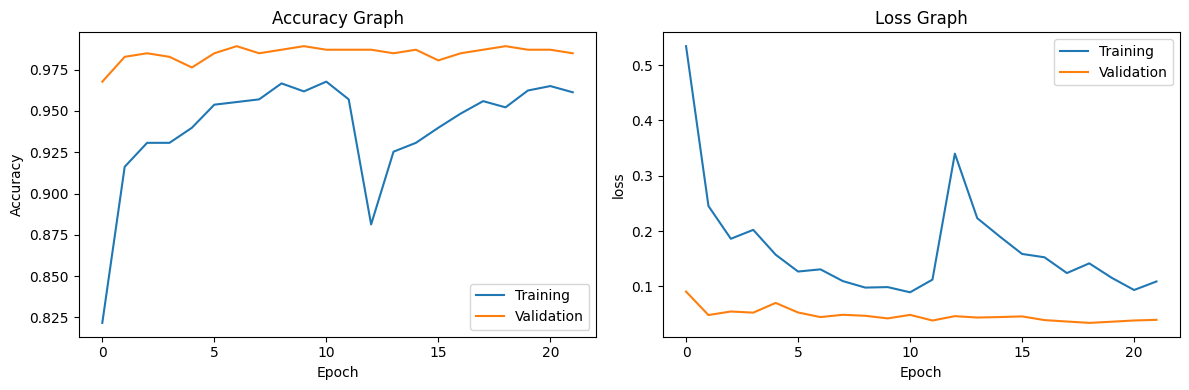

In [57]:
# Combine both histories for plotting

def combine_history(h1,h2,key):
  return h1.history[key]+h2.history[key]

acc=combine_history(history,history1,'accuracy')
val_acc=combine_history(history,history1,'val_accuracy')
loss=combine_history(history, history1, 'loss')
val_loss=combine_history(history, history1, 'val_loss')

# ── Plot Accuracy

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(acc,label='Training')
plt.plot(val_acc,label='Validation')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")


plt.subplot(1,2,2)
plt.plot(loss,label='Training')
plt.plot(val_loss,label='Validation')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epoch")
plt.ylabel("loss")

plt.tight_layout()
plt.show()

In [62]:
import cv2
img=cv2.imread("/content/animal3.jpg")
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(128,128))
img=img/255.0
img=np.expand_dims(img,axis=0)
img.shape

(1, 128, 128, 3)

In [63]:
y_pred=model.predict(img)
y_pred=np.argmax(y_pred)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


np.int64(1)

In [64]:
print("Predictions:",class_names[y_pred])

Predictions: Amur Leopard
